<a href="https://colab.research.google.com/github/Deepikadandolu/SumInt_IISc_ex1/blob/main/tumor_svm(linear).ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import numpy as np
import os
import cv2
import matplotlib.pyplot as plt
import kagglehub
path = kagglehub.dataset_download("sartajbhuvaji/brain-tumor-classification-mri")
from sklearn.model_selection import train_test_split
from sklearn.decomposition import PCA
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, classification_report

Using Colab cache for faster access to the 'brain-tumor-classification-mri' dataset.


In [2]:
# Define classes and labels
classes = {
    'no_tumor': 0,
    'pituitary_tumor': 1,
    'glioma_tumor': 2,
    'meningioma_tumor': 3
}

# Dataset training folder path
train_path = os.path.join(path, "Training")

# Load and preprocess dataset
X = []
Y = []

for cls, label in classes.items():

    class_path = os.path.join(train_path, cls)

    for filename in os.listdir(class_path):

        img_path = os.path.join(class_path, filename)

        # Read image in grayscale
        img = cv2.imread(img_path, 0)

        if img is not None:

            # Resize image
            img = cv2.resize(img, (200, 200))

            # Normalize image
            img = img / 255.0

            # Flatten image
            X.append(img.flatten())

            # Append label
            Y.append(label)

# Convert to numpy arrays
X = np.array(X)
Y = np.array(Y)

print("Dataset loaded successfully")
print("X shape:", X.shape)
print("Y shape:", Y.shape)

Dataset loaded successfully
X shape: (2870, 40000)
Y shape: (2870,)


In [3]:
# Split the dataset into training and testing sets
xtrain, xtest, ytrain, ytest = train_test_split(
    X,
    Y,
    random_state=10,
    test_size=0.2
)

# Apply PCA for dimensionality reduction
pca = PCA(n_components=0.98)

pca_train = pca.fit_transform(xtrain)
pca_test = pca.transform(xtest)

# Train Support Vector Classifier with LINEAR kernel
sv = SVC(kernel='linear')

sv.fit(pca_train, ytrain)

# Evaluate the model
train_score = sv.score(pca_train, ytrain)
test_score = sv.score(pca_test, ytest)

print("Training Score:", train_score)
print("Testing Score:", test_score)

Training Score: 1.0
Testing Score: 0.8013937282229965


In [5]:
# Display sample images and predictions
def display_samples(folder, title, num_samples=9):

    plt.figure(figsize=(12, 8))

    c = 1

    for i, filename in enumerate(os.listdir(folder)[:num_samples]):

        # Read image
        img = cv2.imread(os.path.join(folder, filename), 0)

        # Resize image
        img = cv2.resize(img, (200, 200))

        # Normalize and flatten image
        img_flat = img.flatten() / 255.0

        # Apply PCA transformation
        img_pca = pca.transform([img_flat])

        # Predict using LINEAR SVM
        prediction = sv.predict(img_pca)

        # Display image
        plt.subplot(3, 3, c)

        plt.title(dec[prediction[0]])

        plt.imshow(img, cmap='gray')

        plt.axis('off')

        c += 1

    plt.suptitle(title)

    plt.show()

Predictions using SVM with LINEAR kernel


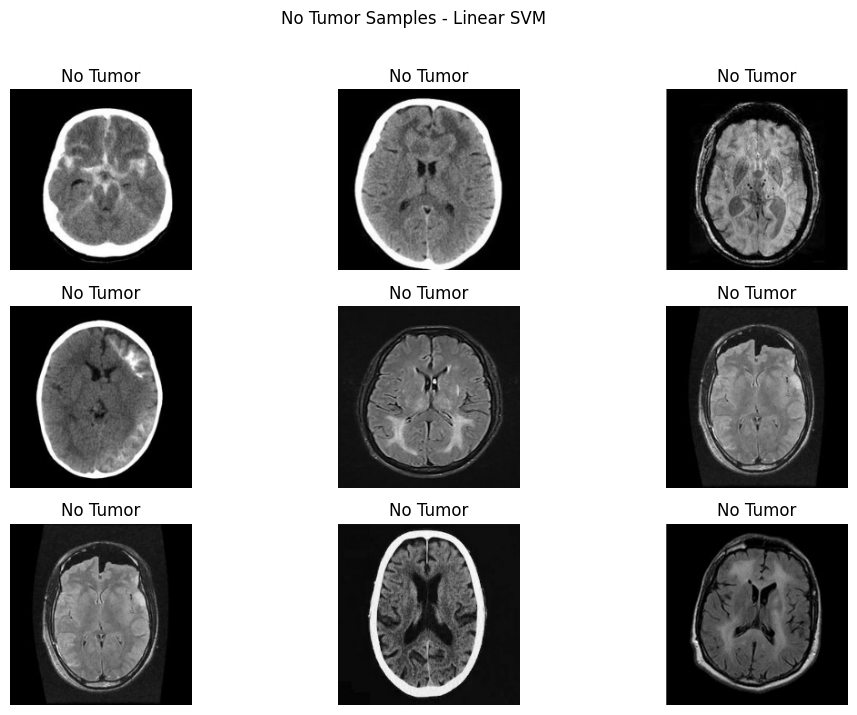

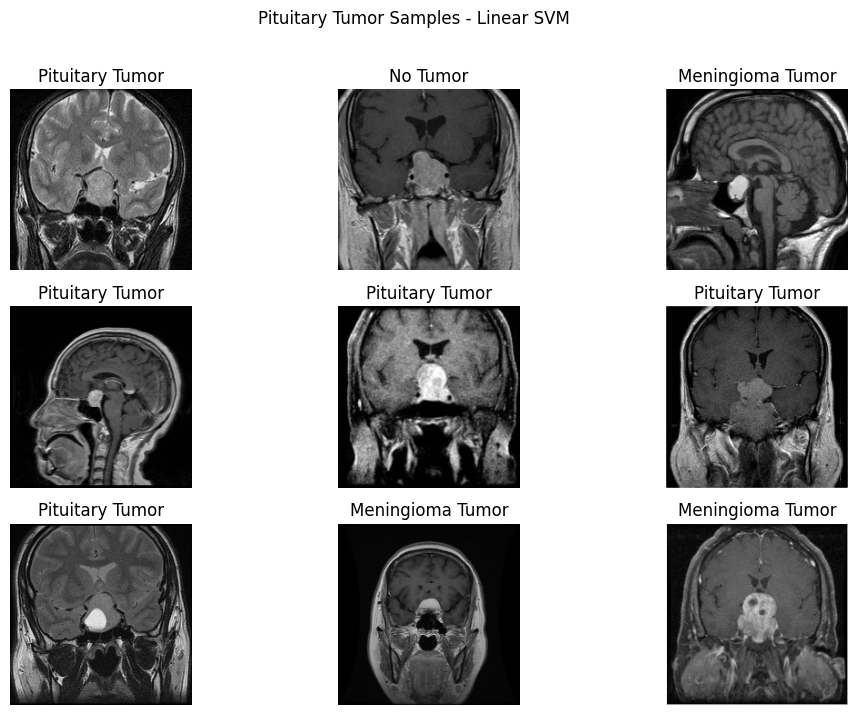

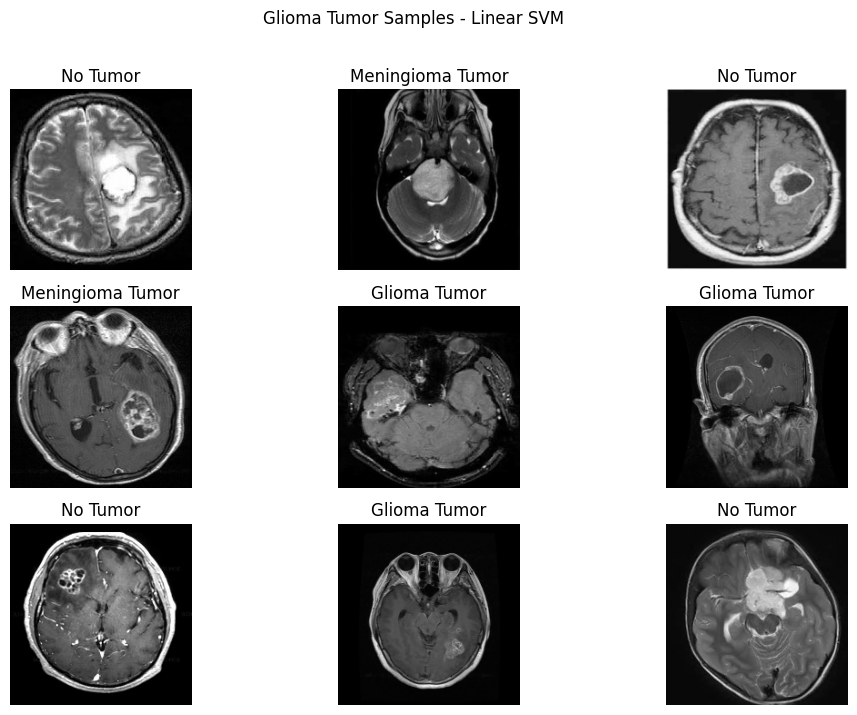

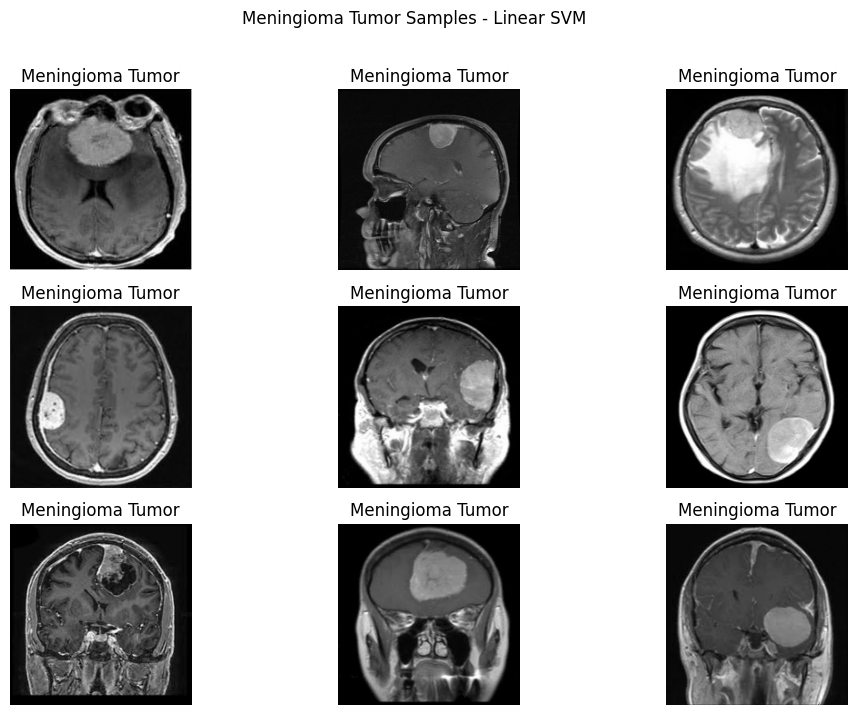

In [6]:
# Define class labels
dec = {
    0: 'No Tumor',
    1: 'Pituitary Tumor',
    2: 'Glioma Tumor',
    3: 'Meningioma Tumor'
}

# Get the base path for the testing dataset
test_path = os.path.join(path, "Testing")

print("Predictions using SVM with LINEAR kernel")

# Display sample images and predictions for each tumor type
tumor_folders = [
    'no_tumor',
    'pituitary_tumor',
    'glioma_tumor',
    'meningioma_tumor'
]

for tumor_folder in tumor_folders:

    folder_path = os.path.join(test_path, tumor_folder)

    title = f'{tumor_folder.replace("_", " ").title()} Samples - Linear SVM'

    display_samples(folder_path, title)

In [7]:
import pandas as pd

# Count the occurrences of each tumor type
tumor_counts = {
    dec[label]: np.sum(Y == label)
    for label in classes.values()
}

# Create table for tumor counts
table_data = {
    'Index': range(1, len(classes) + 1),
    'Tumor Type': list(tumor_counts.keys()),
    'Count': list(tumor_counts.values())
}

tumor_table = pd.DataFrame(table_data)

# Style the table
styled_table = tumor_table.style.set_properties(
    **{
        'border': '3px solid black',
        'text-align': 'center'
    }
)

# Display table
print("\033[1mTumor Type Counts (Linear SVM Dataset):\033[0m")

display(styled_table)

Tumor Type Counts (Linear SVM Dataset):


,Index,Tumor Type,Count
0,1,No Tumor,395
1,2,Pituitary Tumor,827
2,3,Glioma Tumor,826
3,4,Meningioma Tumor,822


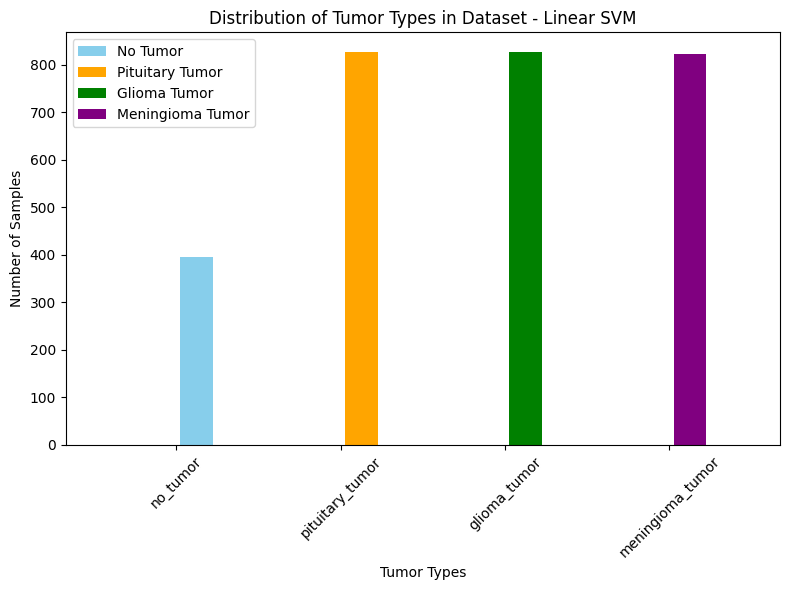

In [8]:
# Create histogram of tumor types for Linear SVM dataset

tumor_labels = [dec[label] for label in Y]

colors = ['skyblue', 'orange', 'green', 'purple']

plt.figure(figsize=(8, 6))

for label, color in zip(classes.values(), colors):

    plt.hist(
        np.array(tumor_labels)[Y == label],
        bins=len(classes),
        align='mid',
        rwidth=0.8,
        color=color,
        label=dec[label]
    )

plt.xlabel('Tumor Types')

plt.ylabel('Number of Samples')

plt.title('Distribution of Tumor Types in Dataset - Linear SVM')

plt.xticks(
    range(len(classes)),
    list(classes.keys()),
    rotation=45
)

plt.legend()

plt.tight_layout()

plt.show()